# Concrete Strength Model Tutorial
In this notebook, we show how to train and interact with the Gaussian process concrete strength model.

In [1]:
import os

import botorch
import matplotlib.pyplot as plt
import pandas as pd
import torch

In [2]:
%matplotlib inline

## System Setup

This cell automatically configures the environment for both local development and CI.

In [3]:
# Configuration: optimization mode can be set via the environment variable
# BOXCRETE_OPTIMIZATION_MODE. Options: "mortar" or "concrete" (default).
optimization_mode = os.environ.get("BOXCRETE_OPTIMIZATION_MODE") or "concrete"
print(f"Optimization mode: {optimization_mode}")

Optimization mode: concrete


## Load Data
Assumption on data format:
- The "Mix ID" column contains entries of the format `<batch_name>_<mix_number>`, e.g. `Feb_2023_0` separates into a batch_name `Feb_2023` and a mix number `0`. Feel free to raise a GitHub issue if this format is restrictive for your use case.

In [4]:
from boxcrete.utils import DATA_PATH
data_path = DATA_PATH
df = pd.read_csv(data_path, delimiter=",")

In [5]:
from boxcrete import utils
from boxcrete.utils import (
    get_bounds,
    get_constraints,
    MORTAR_BOUNDS_DICT,
    MORTAR_CONSTRAINTS,
)

data = utils.load_concrete_strength(data_path=data_path)

# Always use default (concrete) bounds for training since the model
# trains on all data (mortar + concrete). Mortar/concrete-specific
# bounds are used for optimization constraints (below).
data.bounds = get_bounds(data.X_columns)

In [6]:
data.X_columns  # model inputs

['Cement (kg/m3)',
 'Fly Ash (kg/m3)',
 'Slag (kg/m3)',
 'Water (kg/m3)',
 'HRWR (kg/m3)',
 'MRWR (kg/m3)',
 'Fine Aggregate (kg/m3)',
 'Coarse Aggregates (kg/m3)',
 'Material Source',
 'Temp (C)',
 'Time']

In [7]:
X, Y, Yvar, X_bounds = data.strength_data  # strength data contains all time-dependent data

## Load Search Space Constraints

In [8]:
if optimization_mode == "mortar":
    bounds = get_bounds(data.X_columns[:-1], MORTAR_BOUNDS_DICT)
else:
    bounds = get_bounds(data.X_columns[:-1])  # excluding time

In [9]:
if optimization_mode == "mortar":
    equality_constraints, inequality_constraints = get_constraints(
        data.X_columns[:-1], **MORTAR_CONSTRAINTS
    )
else:
    equality_constraints, inequality_constraints = get_constraints(
        data.X_columns[:-1]
    )

## Define and Fit Model
1. fit strength model
2. fit GWP model
3. unify as composition-input-only with fixed-time outputs

In [10]:
from boxcrete import models

In [11]:
model_strength_days = [1, 28]  # the strength days that are converted to optimization objectives
model = models.SustainableConcreteModel(strength_days=model_strength_days)

In [12]:
model.fit_gwp_model(data)

SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): LogTransformedInterval(1.000E-04, 1.000E+00)
    )
  )
  (mean_module): ZeroMean()
  (covar_module): LinearKernel(
    (raw_variance_constraint): Positive()
  )
)

In [13]:
# use_fixed_noise=False because with only 3 measurements per sample,
# we can't trust the empirical variance completely. Instead, we infer
# the noise level using marginal likelihood optimization.
model.fit_strength_model(data, use_fixed_noise=False)

SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): LogTransformedInterval(1.000E-06, 1.000E+00)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): AdditiveKernel(
    (kernels): ModuleList(
      (0): ScaleKernel(
        (base_kernel): MaternKernel(
          (raw_lengthscale_constraint): LogTransformedInterval(1.000E-02, 1.000E+03)
        )
        (raw_outputscale_constraint): LogTransformedInterval(1.000E-02, 1.000E+02)
      )
      (1): ScaleKernel(
        (base_kernel): RBFKernel(
          (raw_lengthscale_constraint): LogTransformedInterval(1.000E-02, 1.000E+03)
        )
        (raw_outputscale_constraint): LogTransformedInterval(1.000E-02, 1.000E+02)
      )
    )
  )
  (outcome_transform): Standardize()
  (input_transform): ChainedInputTransform(
    (tf1): AffineInputTransform()
    (tf2): Log10()
    (tf3): Normalize()
  )
)

In [14]:
# Build fixed_features based on optimization mode.
# In mortar mode, Coarse Aggregates and Material Source are fixed.
# In concrete mode, only Material Source is fixed (Coarse Aggregates is optimized).
fixed_features = {}
X_cols = data.X_columns[:-1]  # exclude Time (handled by get_model_list)

if optimization_mode == "mortar":
    coarse_idx = data.X_columns.index("Coarse Aggregates (kg/m3)")
    fixed_features[coarse_idx] = 0.0

if "Material Source" in data.X_columns:
    ms_idx = data.X_columns.index("Material Source")
    fixed_features[ms_idx] = 0.0  # default material source

model_list = model.get_model_list(fixed_features=fixed_features if fixed_features else None)

# Compute optimization-space column names (excluding Time and fixed features)
time_idx = data.X_columns.index("Time")
fixed_features_opt = {k: v for k, v in fixed_features.items() if k != time_idx}
opt_columns = [
    col for i, col in enumerate(data.X_columns[:-1])
    if i not in fixed_features_opt
]
print(f"Full columns (no Time): {data.X_columns[:-1]}")
print(f"Optimization columns: {opt_columns}")
print(f"Fixed features: {fixed_features}")


Full columns (no Time): ['Cement (kg/m3)', 'Fly Ash (kg/m3)', 'Slag (kg/m3)', 'Water (kg/m3)', 'HRWR (kg/m3)', 'MRWR (kg/m3)', 'Fine Aggregate (kg/m3)', 'Coarse Aggregates (kg/m3)', 'Material Source', 'Temp (C)']
Optimization columns: ['Cement (kg/m3)', 'Fly Ash (kg/m3)', 'Slag (kg/m3)', 'Water (kg/m3)', 'HRWR (kg/m3)', 'MRWR (kg/m3)', 'Fine Aggregate (kg/m3)', 'Coarse Aggregates (kg/m3)', 'Temp (C)']
Fixed features: {8: 0.0}


## GWP Fit on Training Set

The GWP "observations" come from a linear model in the default dataset, so "predictions" of GWP are perfect. However, note that the methods allow for arbitrary, even a-priori non-predictable quantifications of sustainability.

In [15]:
# GWP calibration: use raw gwp_model (model_list has FixedFeatureModel wrappers
# that change the input dims for optimization, not suitable for calibration).
X, Y, Yvar, X_bounds = data.gwp_data
ind = range(len(X))
gwp_post = model.gwp_model.posterior(X)

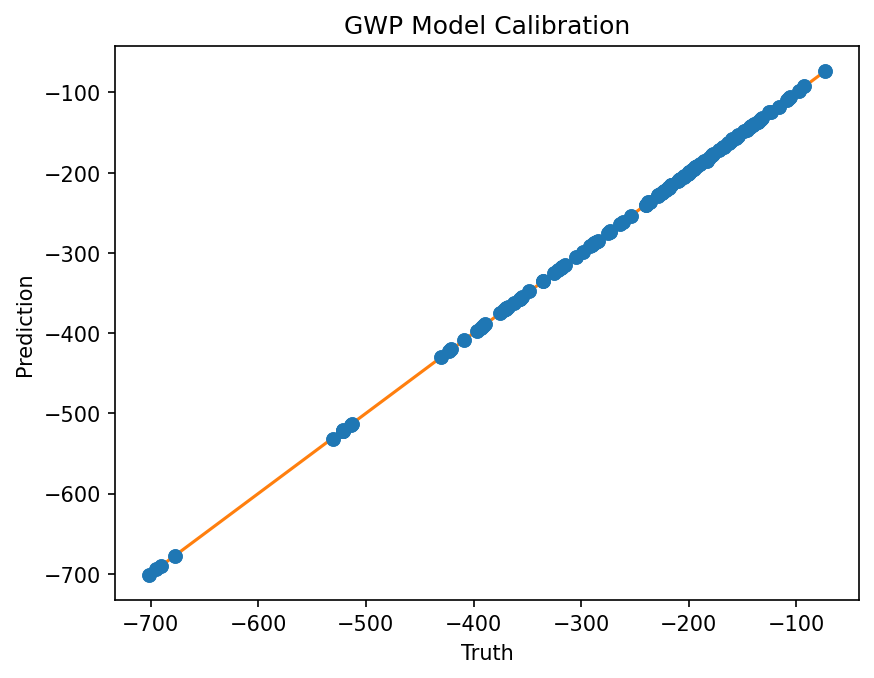

In [16]:
obj_id = 0
truth = Y[ind].detach()
pred = gwp_post.mean.squeeze(-1).detach()
truth_std = Yvar[ind][ind].sqrt().detach()
pred_std = gwp_post.variance.squeeze(-1).sqrt().detach()
plt.figure(dpi=150)
plt.title("GWP Model Calibration")
plt.ylabel("Prediction")
plt.xlabel("Truth")
plt.scatter(truth, pred)
plt.errorbar(truth, pred, yerr=2*pred_std, fmt="o")
line = torch.arange(truth.min(), truth.max())
plt.plot(line, line)

## Strength Fit on Training Set

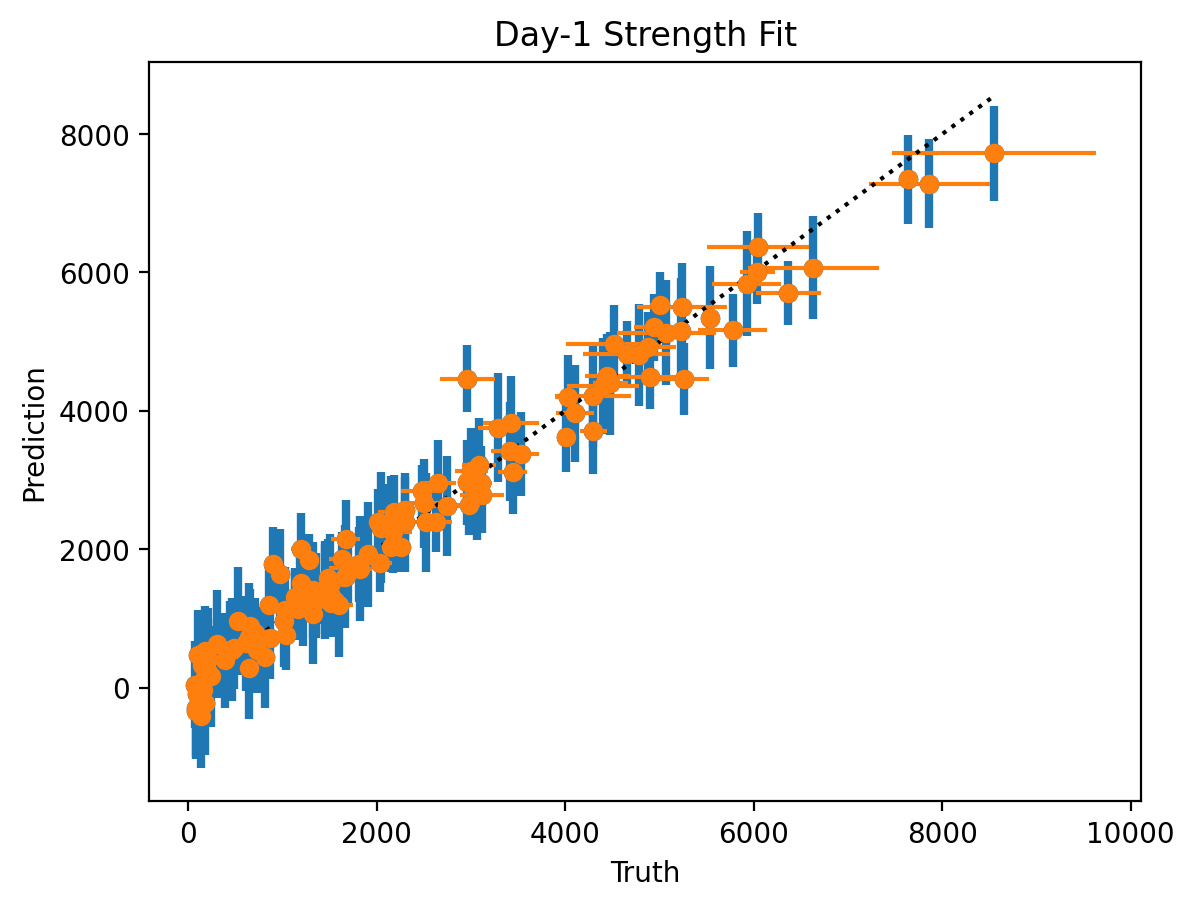

In [17]:
time = 1
Xt, truth, truth_var = data.strength_data_by_time(time)
truth = truth.squeeze(-1).detach()
truth_std = truth_var.sqrt().squeeze(-1).detach()

post_t = model.strength_model.posterior(Xt)
pred = post_t.mean.squeeze(-1).detach()
pred_std = post_t.variance.sqrt().squeeze(-1).detach()

fig = plt.figure(dpi=200)
plt.title(f"Day-{time} Strength Fit")
plt.ylabel("Prediction")
plt.xlabel("Truth")
plt.scatter(truth, pred)
lw = 3
plt.errorbar(truth, pred, yerr=2 * pred_std, fmt="o", linewidth=lw)
plt.errorbar(truth, pred, xerr=2 * truth_std, fmt="o", linewidth=lw / 2)
line = torch.arange(truth.min(), truth.max())
plt.plot(line, line, color="black", linestyle=":")
plt.show()

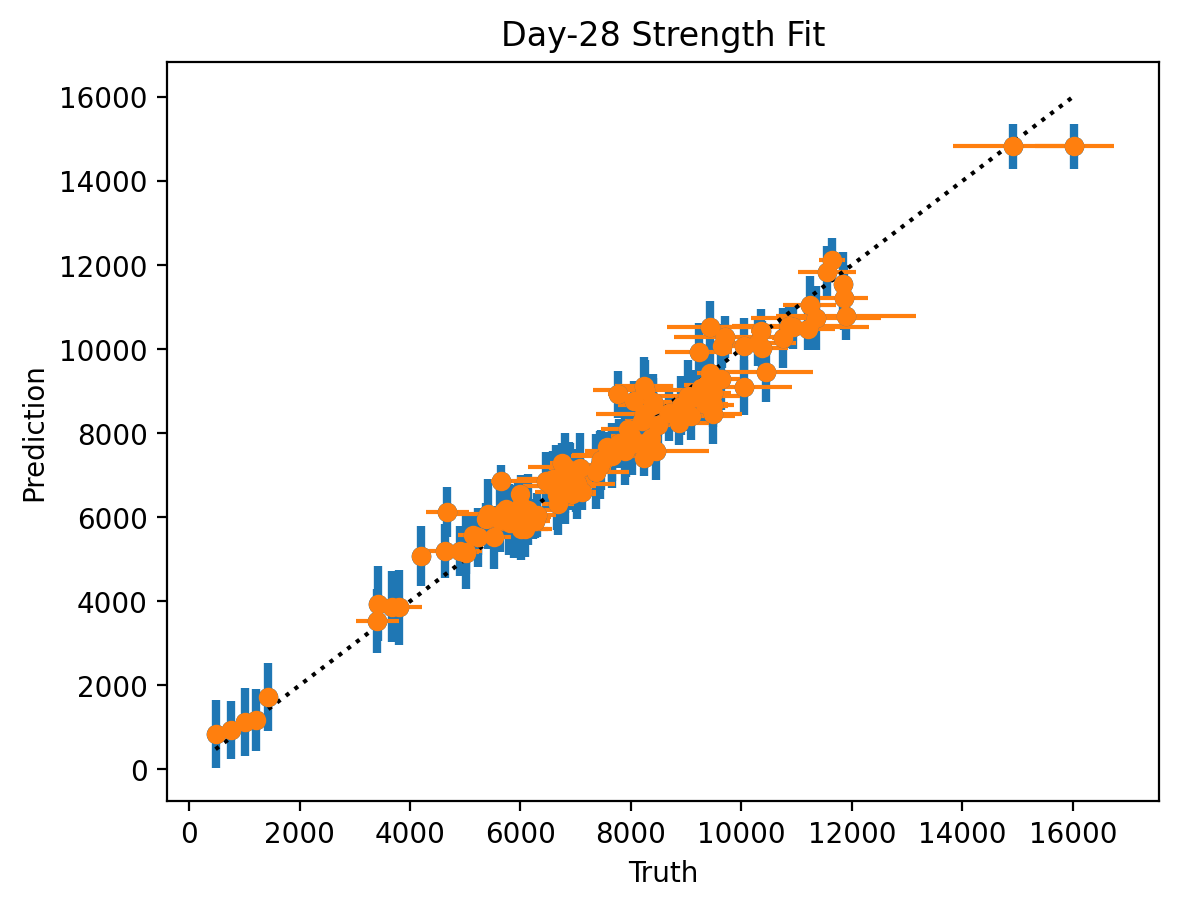

In [18]:
time = 28
Xt, truth, truth_var = data.strength_data_by_time(time)
truth = truth.squeeze(-1).detach()
truth_std = truth_var.sqrt().squeeze(-1).detach()

post_t = model.strength_model.posterior(Xt)
pred = post_t.mean.squeeze(-1).detach()
pred_std = post_t.variance.sqrt().squeeze(-1).detach()

fig = plt.figure(dpi=200)
plt.title(f"Day-{time} Strength Fit")
plt.ylabel("Prediction")
plt.xlabel("Truth")
plt.scatter(truth, pred)
lw = 3
plt.errorbar(truth, pred, yerr=2 * pred_std, fmt="o", linewidth=lw)
plt.errorbar(truth, pred, xerr=2 * truth_std, fmt="o", linewidth=lw / 2)
line = torch.arange(truth.min(), truth.max())
plt.plot(line, line, color="black", linestyle=":")

# Compute Predicted Pareto Frontier
This section uses a Polytope sampler to generate a random set of points satisfying the (adjusted) constraints and computing the Pareto frontier based on the predictive mean of the model. See the qLogNEHVI section below for gradient-based optimization of the predicted Pareto frontier.

In [19]:
# this is the reference point for the Pareto frontier,
# representing the lower bounds on 1) -GWP, 2) 1-day, and
# 3) 28-day strength below which solutions become irrelevant.
ref_point = utils.get_reference_point(optimization_mode)
ref_point

tensor([-200., 1000., 5000.], dtype=torch.float64)

In [20]:
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

tableau = list(mcolors.TABLEAU_COLORS.values())

# Compute bounds in the optimization (reduced) space.
# opt_columns excludes fixed-feature dimensions so bounds/constraints
# match the input dimension expected by model_list.
if optimization_mode == "mortar":
    opt_bounds = get_bounds(opt_columns, MORTAR_BOUNDS_DICT)
else:
    opt_bounds = get_bounds(opt_columns)

fly_ash_idx = opt_columns.index("Fly Ash (kg/m3)")
slag_idx = opt_columns.index("Slag (kg/m3)")

all_bounds = opt_bounds.clone()

noash_bounds = opt_bounds.clone()
noash_bounds[1, fly_ash_idx] = 0.0  # no fly ash
noslag_bounds = opt_bounds.clone()
noslag_bounds[1, slag_idx] = 0.0  # no slag

# define a sequence of different constraints
wb_ratios = [0.2, 0.35, 0.2, 0.35, 0.2, 0.35]
bounds_list = [all_bounds, all_bounds, noash_bounds, noash_bounds, noslag_bounds, noslag_bounds]
names = ["all, w/b > 0.20", "all, w/b > 0.35", "no ash, w/b > 0.20", "no ash, w/b > 0.35", "no slag, w/b > 0.20", "no slag, w/b > 0.35"]
colors = [tableau[0], tableau[0], tableau[1], tableau[1], tableau[2], tableau[2]]
linestyles = ["-", ":", "-", ":", "-", ":"]


### Predicted GWP-1-day-strength trade-off

In [21]:
def get_inferred_pareto_frontiers(pareto_dims: list[int], num_candidates: int):
    X_all = []
    Y_all = []
    Ystd_all = []
    for bnds, min_wb, name in zip(bounds_list, wb_ratios, names):
        if optimization_mode == "mortar":
            eq, ineq = get_constraints(
                opt_columns,
                **{**MORTAR_CONSTRAINTS, "water_binder_bounds": (min_wb, 0.5)},
            )
        else:
            eq, ineq = get_constraints(
                opt_columns, water_binder_bounds=(min_wb, 0.5)
            )
        X_pareto, Y_pareto, Ystd_pareto = utils.predict_pareto(
            model_list,
            pareto_dims=pareto_dims,
            ref_point=ref_point,
            bounds=bnds,
            equality_constraints=eq,
            inequality_constraints=ineq,
            num_candidates=num_candidates,
        )
        X_all.append(X_pareto.detach().numpy())
        Y_all.append(Y_pareto.detach().numpy())
        Ystd_all.append(Ystd_pareto.detach().numpy())
    return Y_all, Ystd_all


In [22]:
predicted_pareto_results = []
for strength_dim in [1, 2]:
    pareto_dims = [
        0,
        strength_dim,
    ]  # change second dimension to compute either 1-day or 28-day plot
    predicted_pareto_results.append(
        get_inferred_pareto_frontiers(
            pareto_dims,
            num_candidates=10000,  # number of random composition candidates from which to pick the Pareto-optimal ones.
        )
    )

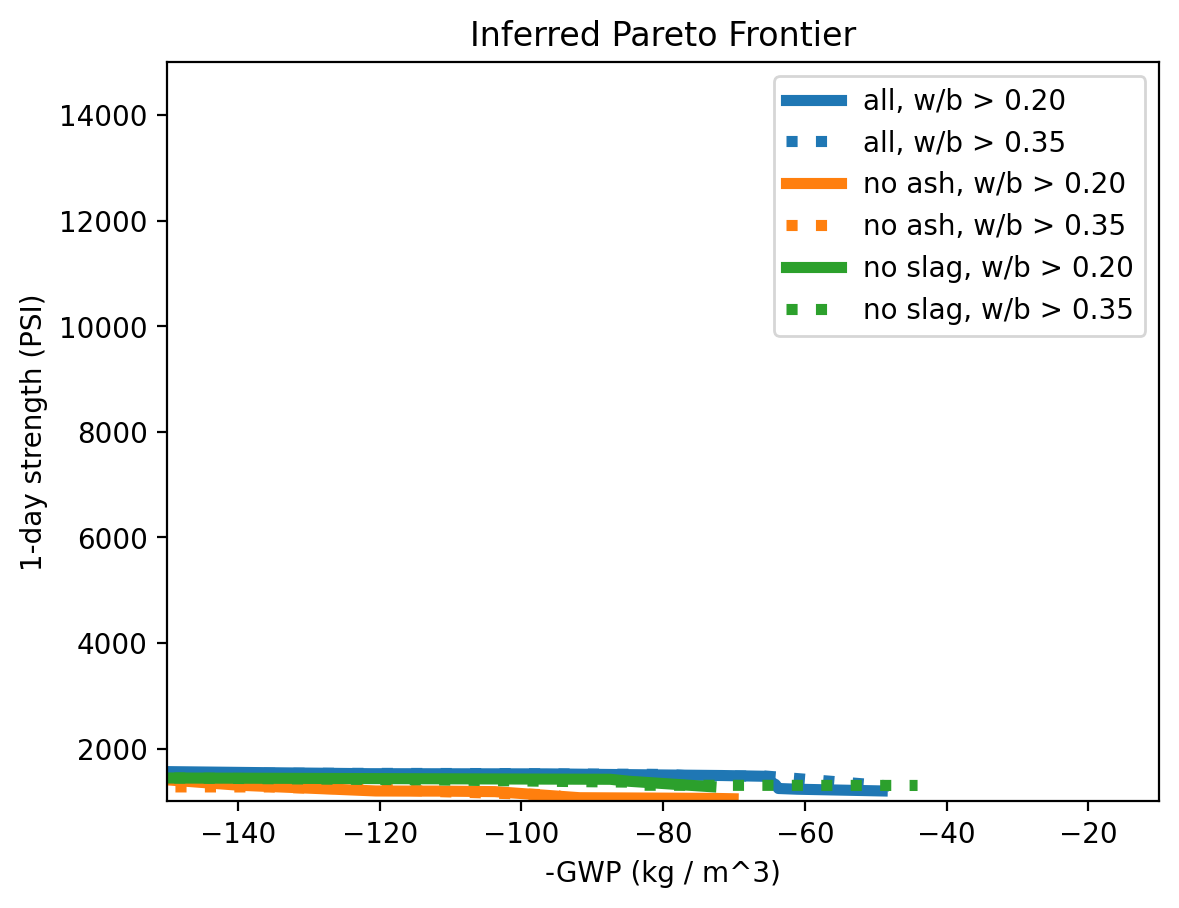

In [23]:
fig = plt.figure(dpi=200)
plt.title("Inferred Pareto Frontier")
plt.ylabel("1-day strength (PSI)")
plt.xlabel("-GWP (kg / m^3)")
Y_all, Ystd_all = predicted_pareto_results[0]
for Y, Ystd, name, ls, color in zip(Y_all, Ystd_all, names, linestyles, colors):
    plt.plot(Y[:, 0], Y[:, 1], label=name, linestyle=ls, color=color, lw=4)
    # can also plot predictive uncertainties, but this gets messy
    # plt.fill_between(Y[:, 0], Y[:, 1] + Ystd[:, 1], Y[:, 1] - Ystd[:, 1], alpha=.5, color=color)

xlim = (-150, -10)
ylim = (1000, 15000)
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()

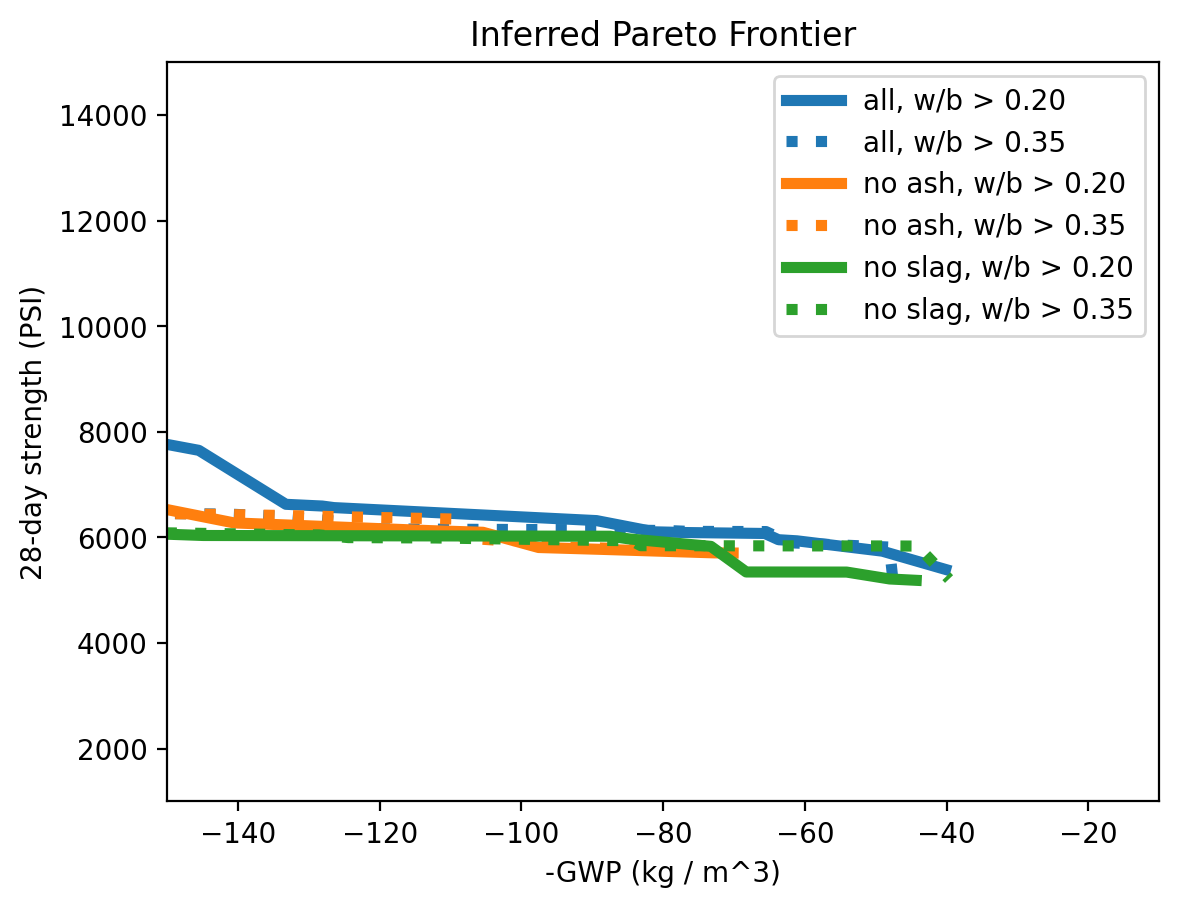

In [24]:
fig = plt.figure(dpi=200)
plt.title("Inferred Pareto Frontier")
plt.ylabel("28-day strength (PSI)")
plt.xlabel("-GWP (kg / m^3)")
Y_all, Ystd_all = predicted_pareto_results[1]
for Y, Ystd, name, ls, color in zip(Y_all, Ystd_all, names, linestyles, colors):
    plt.plot(Y[:, 0], Y[:, 1], label=name, linestyle=ls, color=color, lw=4)
    # plt.fill_between(Y[:, 0], Y[:, 1] + Ystd[:, 1], Y[:, 1] - Ystd[:, 1], alpha=.5, color=color)

xlim = (-150, -10)
ylim = (1000, 15000)
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()

# Gradient-Based Experimental Design with qLogNEHVI

The previous section used random sampling to approximate the Pareto frontier. Here, we use BoTorch's `qLogNoisyExpectedHypervolumeImprovement` acquisition function to find optimal next experiments via gradient-based optimization. This jointly proposes `q` candidate mixtures that maximize the expected improvement in the Pareto hypervolume.

In [25]:
from botorch.acquisition.multi_objective import qLogNoisyExpectedHypervolumeImprovement

# Use the model_list for optimization (reduced space with fixed features)
# X_baseline: the training data projected into the optimization space
X_gwp = data.gwp_data[0]
# Remove fixed-feature columns to get the optimization-space baseline
fixed_indices_no_time = sorted(
    k for k in (fixed_features or {}).keys()
    if k != data.X_columns.index("Time")
)
keep_mask = [i for i in range(X_gwp.shape[-1]) if i not in fixed_indices_no_time]
X_baseline = X_gwp[:, keep_mask]

acqf = qLogNoisyExpectedHypervolumeImprovement(
    model=model_list,
    ref_point=ref_point,
    X_baseline=X_baseline,
    prune_baseline=False,
)

In [26]:
from botorch.optim.optimize import optimize_acqf

q = 5  # number of candidate mixtures to propose jointly
X_next, acq_val = optimize_acqf(
    acq_function=acqf,
    q=q,
    num_restarts=5,
    raw_samples=512,
    bounds=opt_bounds,
    sequential=True,
    equality_constraints=equality_constraints,
    inequality_constraints=inequality_constraints,
    options={"disp": True, "batch_limit": 1},
)
print(f"Acquisition value: {acq_val.item():.4f}" if acq_val.dim() == 0 else f"Acquisition values: {acq_val.tolist()}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.900353318644083
            Iterations: 37
            Function evaluations: 37
            Gradient evaluations: 37


Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.909386881728015
            Iterations: 35
            Function evaluations: 35
            Gradient evaluations: 35


Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.86259108320743
            Iterations: 28
            Function evaluations: 28
            Gradient evaluations: 28


Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.797553077569084
            Iterations: 45
            Function evaluations: 45
            Gradient evaluations: 45


Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.914627126458544
            Iterations: 38
            Function evaluations: 38
            Gradient evaluations: 38


...

Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.03450032508974
            Iterations: 30
            Function evaluations: 30
            Gradient evaluations: 30


Optimization terminated successfully    (Exit mode 0)
            Current function value: -17.942347070555236
            Iterations: 37
            Function evaluations: 37
            Gradient evaluations: 37


Optimization terminated successfully    (Exit mode 0)
            Current function value: -17.673450092028006
            Iterations: 28
            Function evaluations: 28
            Gradient evaluations: 28


Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.039666972834752
            Iterations: 38
            Function evaluations: 39
            Gradient evaluations: 38


Optimization terminated successfully    (Exit mode 0)
            Current function value: -17.862780974419255
            Iterations: 23
            Function evaluations: 24
            Gradient evaluations: 23
Acquisition values: [18.914627126458544, 19.501279682470432, 18.404009785305714, 18.252988925657906, 18.03450032508976]


In [27]:
# Show proposed candidates with predicted objectives
X_next_df = pd.DataFrame(X_next.detach().numpy(), columns=opt_columns)

# Add predicted GWP and strengths
preds = model_list.posterior(X_next).mean.detach()
X_next_df["-GWP"] = preds[:, 0].numpy()
for i, day in enumerate(model_strength_days):
    X_next_df[f"Day-{day} Strength (Pred.)"] = preds[:, i + 1].numpy()

# Add water/binder ratio
binder_cols = [c for c in opt_columns if c in ["Cement (kg/m3)", "Fly Ash (kg/m3)", "Slag (kg/m3)"]]
X_next_df["W/B Ratio"] = X_next_df.apply(
    lambda row: row["Water (kg/m3)"] / max(sum(row[c] for c in binder_cols), 1e-6),
    axis=1,
)

pd.options.display.float_format = '{:.1f}'.format
X_next_df

,Cement (kg/m3),Fly Ash (kg/m3),Slag (kg/m3),Water (kg/m3),HRWR (kg/m3),MRWR (kg/m3),Fine Aggregate (kg/m3),Coarse Aggregates (kg/m3),Temp (C),-GWP,Day-1 Strength (Pred.),Day-28 Strength (Pred.),W/B Ratio
0,0.0,600.0,86.0,343.0,0.0,1.0,2289.6,1081.5,0.0,-35.2,1474.3,6072.8,0.5
1,153.6,149.8,353.9,131.5,0.0,0.9,1211.3,1600.0,25.2,-160.6,2937.4,11367.2,0.2
2,0.0,600.0,162.7,381.4,0.0,0.0,1898.7,881.2,40.0,-40.0,1494.5,6103.1,0.5
3,0.0,600.0,0.0,120.0,0.0,0.0,2183.7,1113.6,0.0,-27.7,1286.0,5812.2,0.2
4,0.0,547.0,356.4,451.7,0.0,1.0,1019.6,1600.0,0.0,-55.0,1528.3,6133.5,0.5


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Mono'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


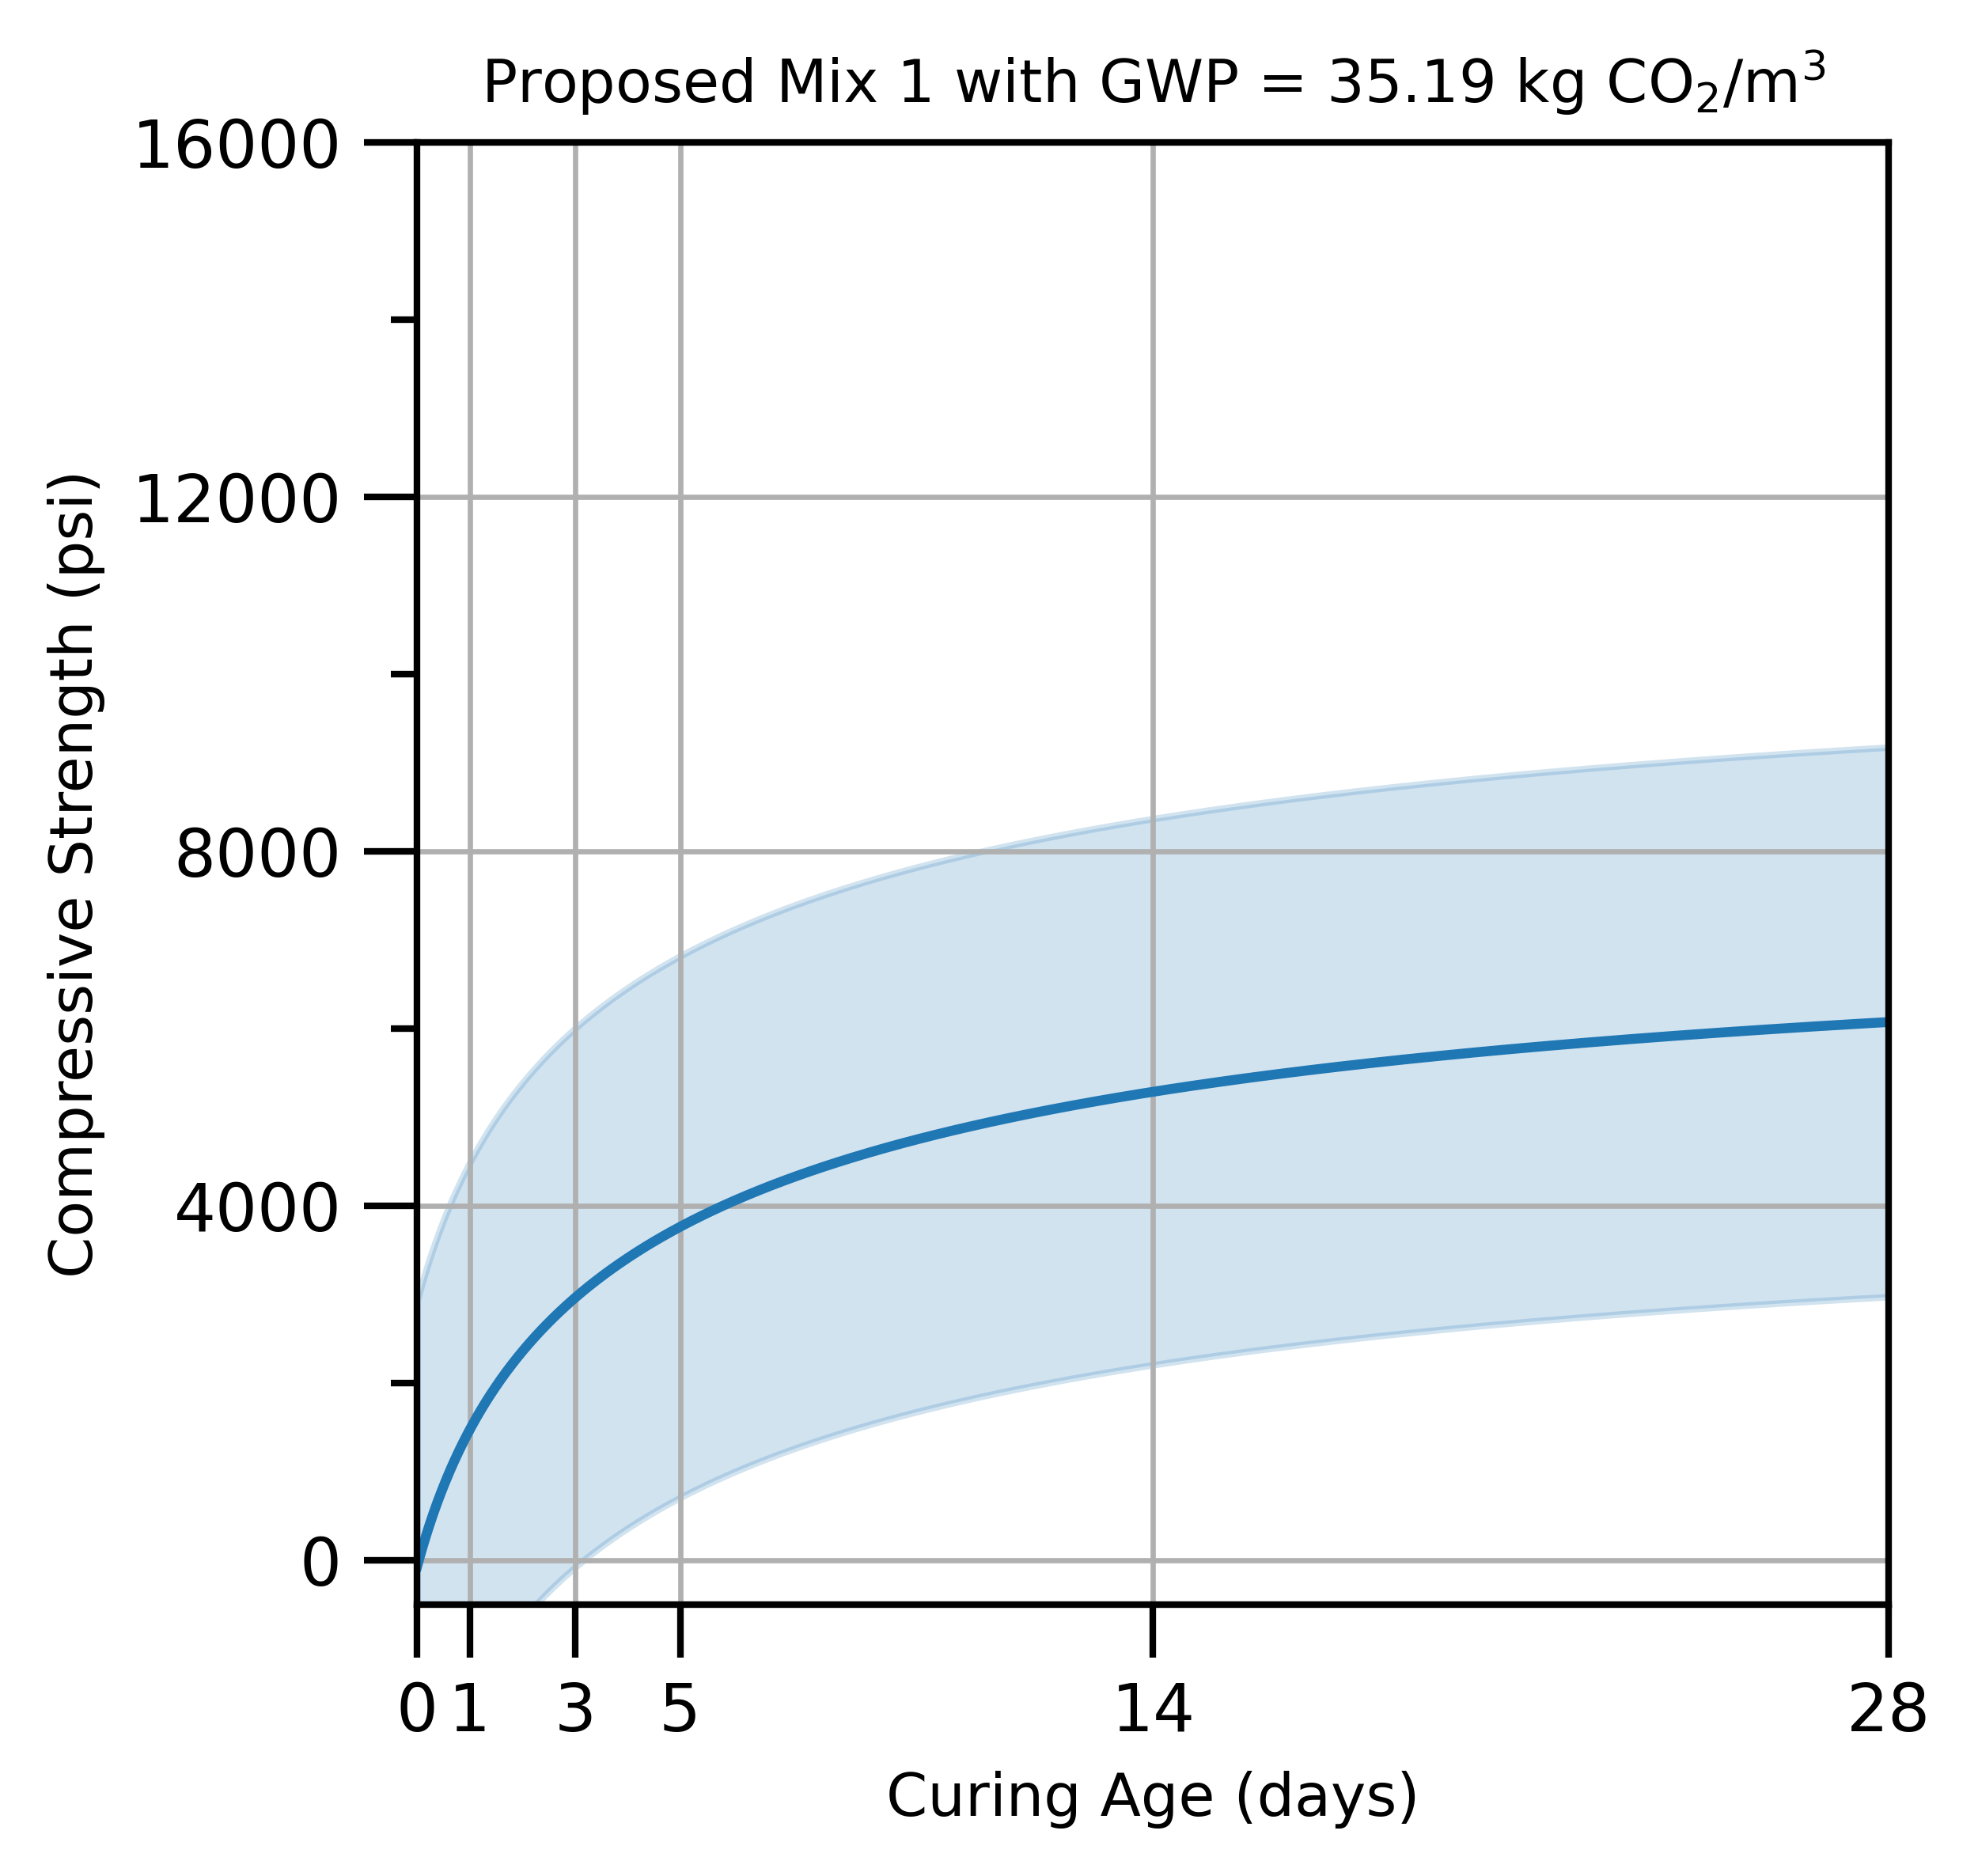

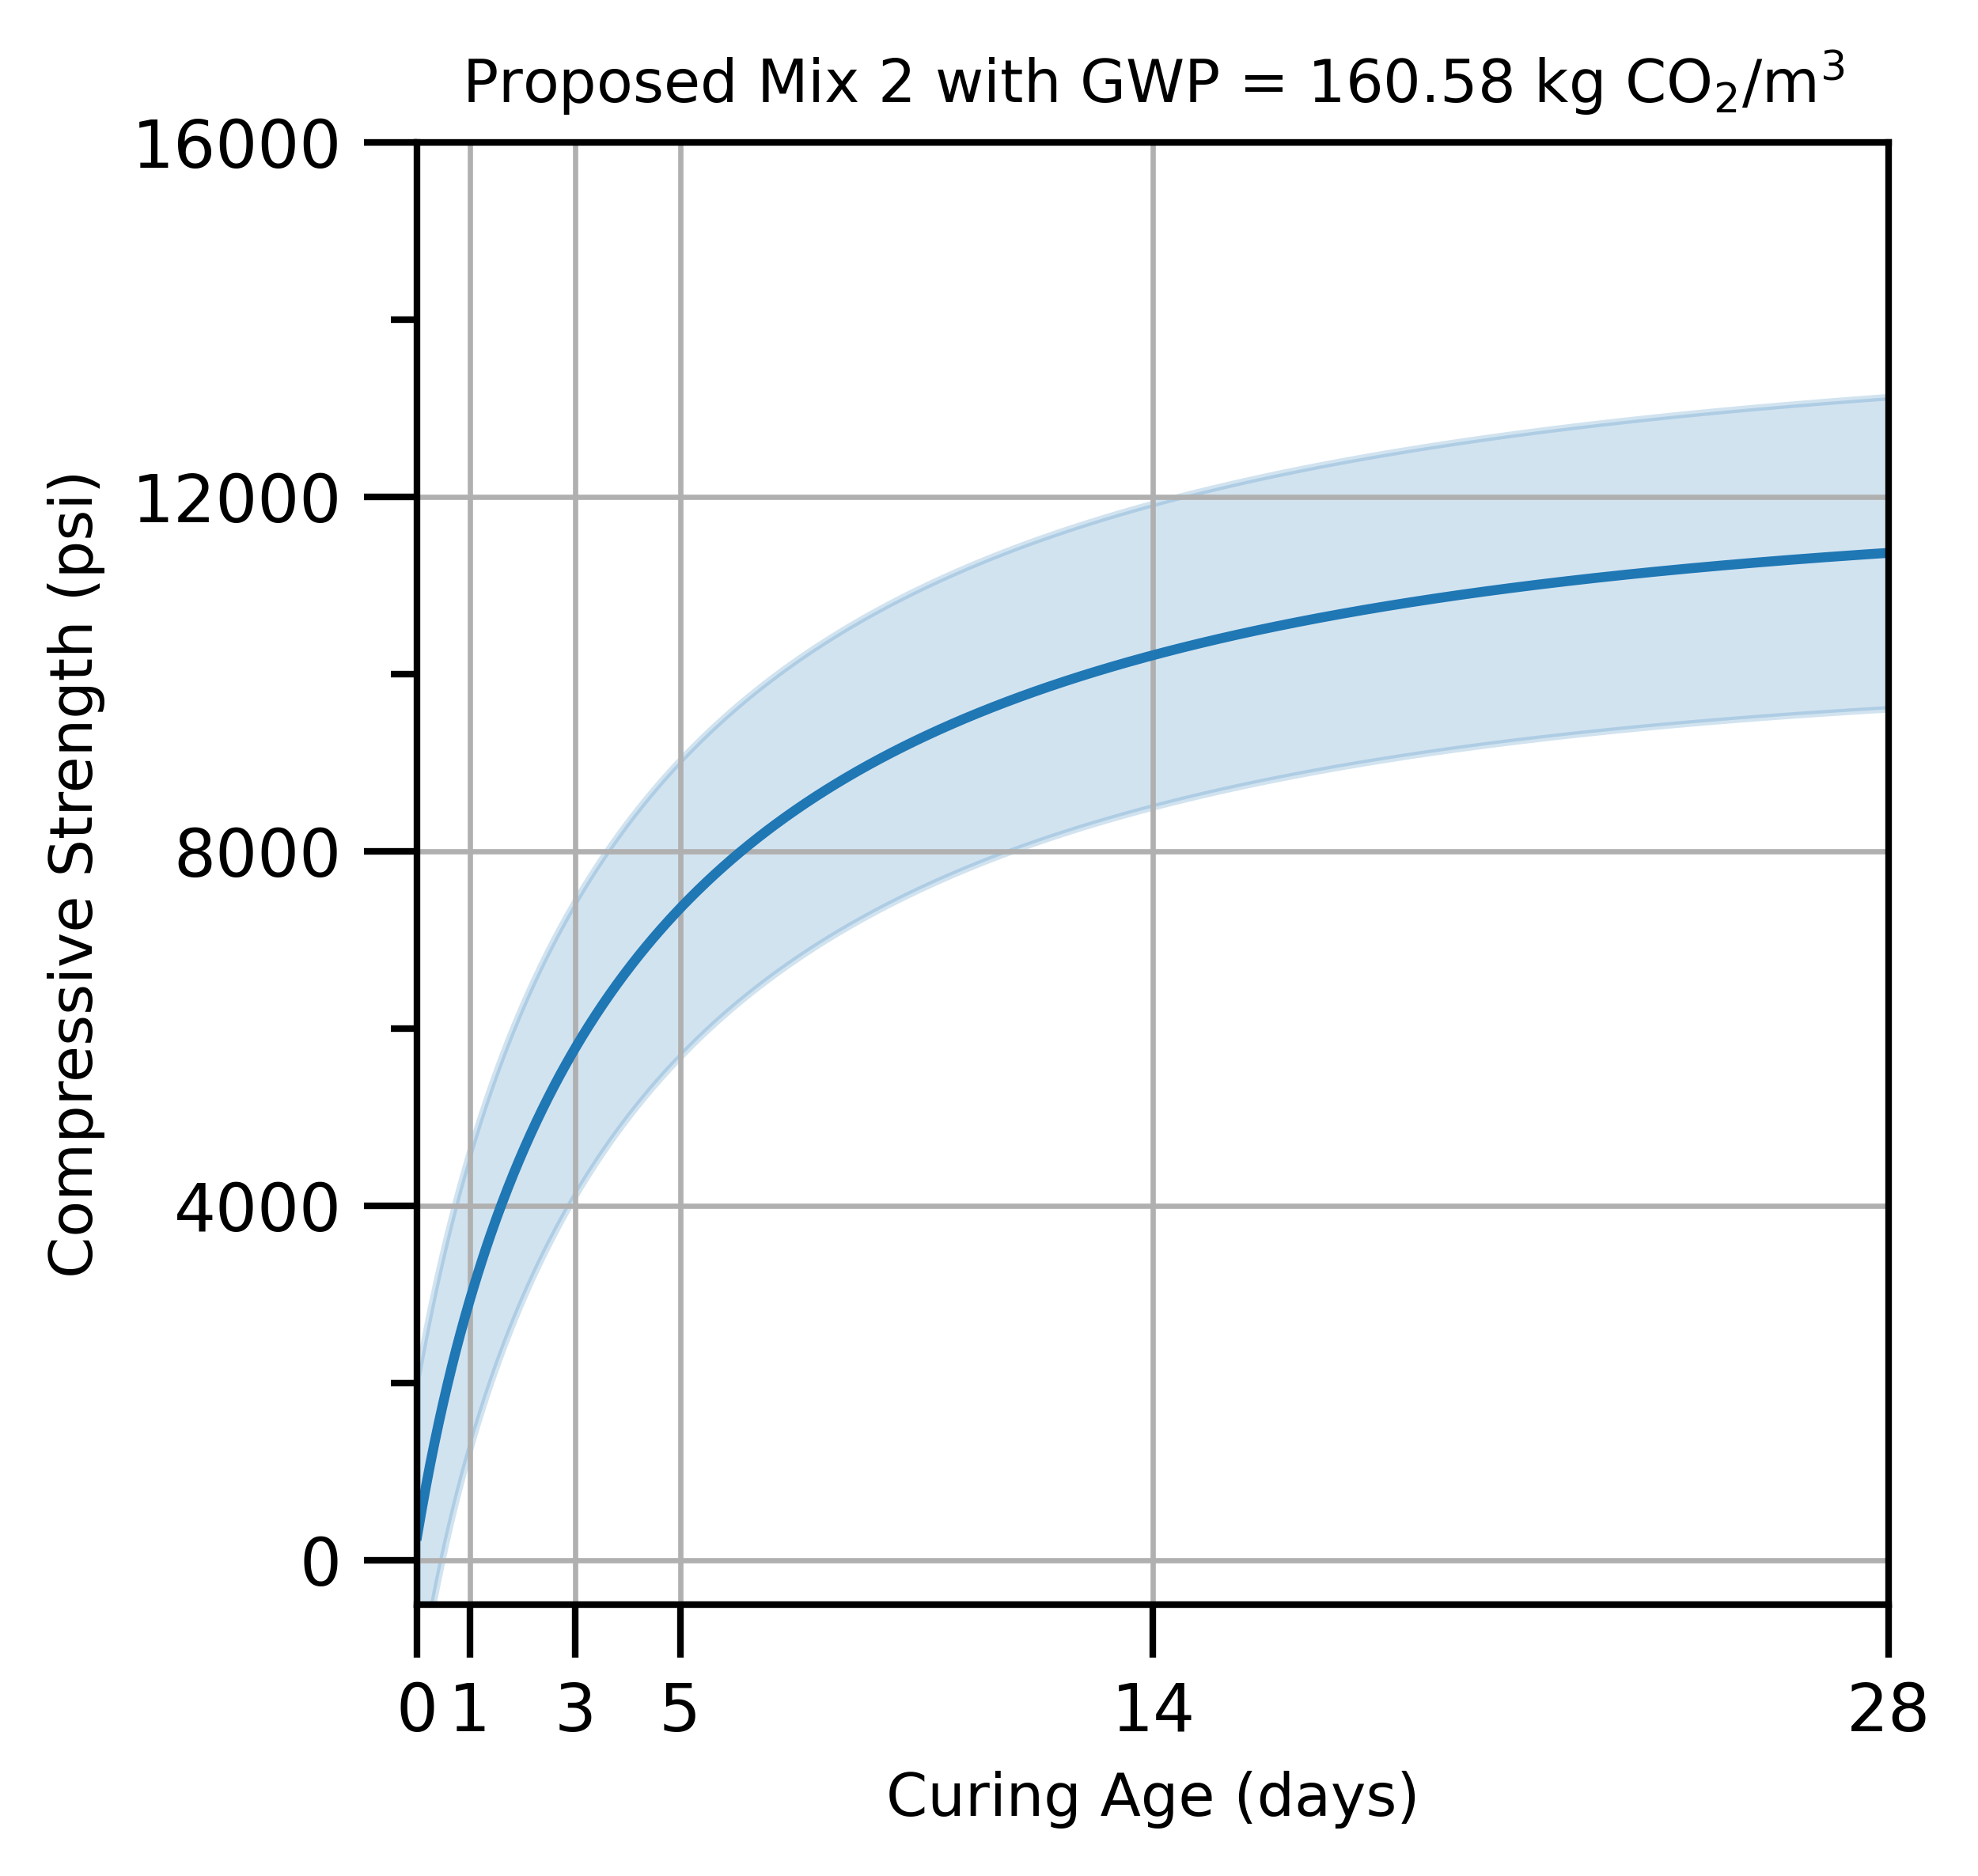

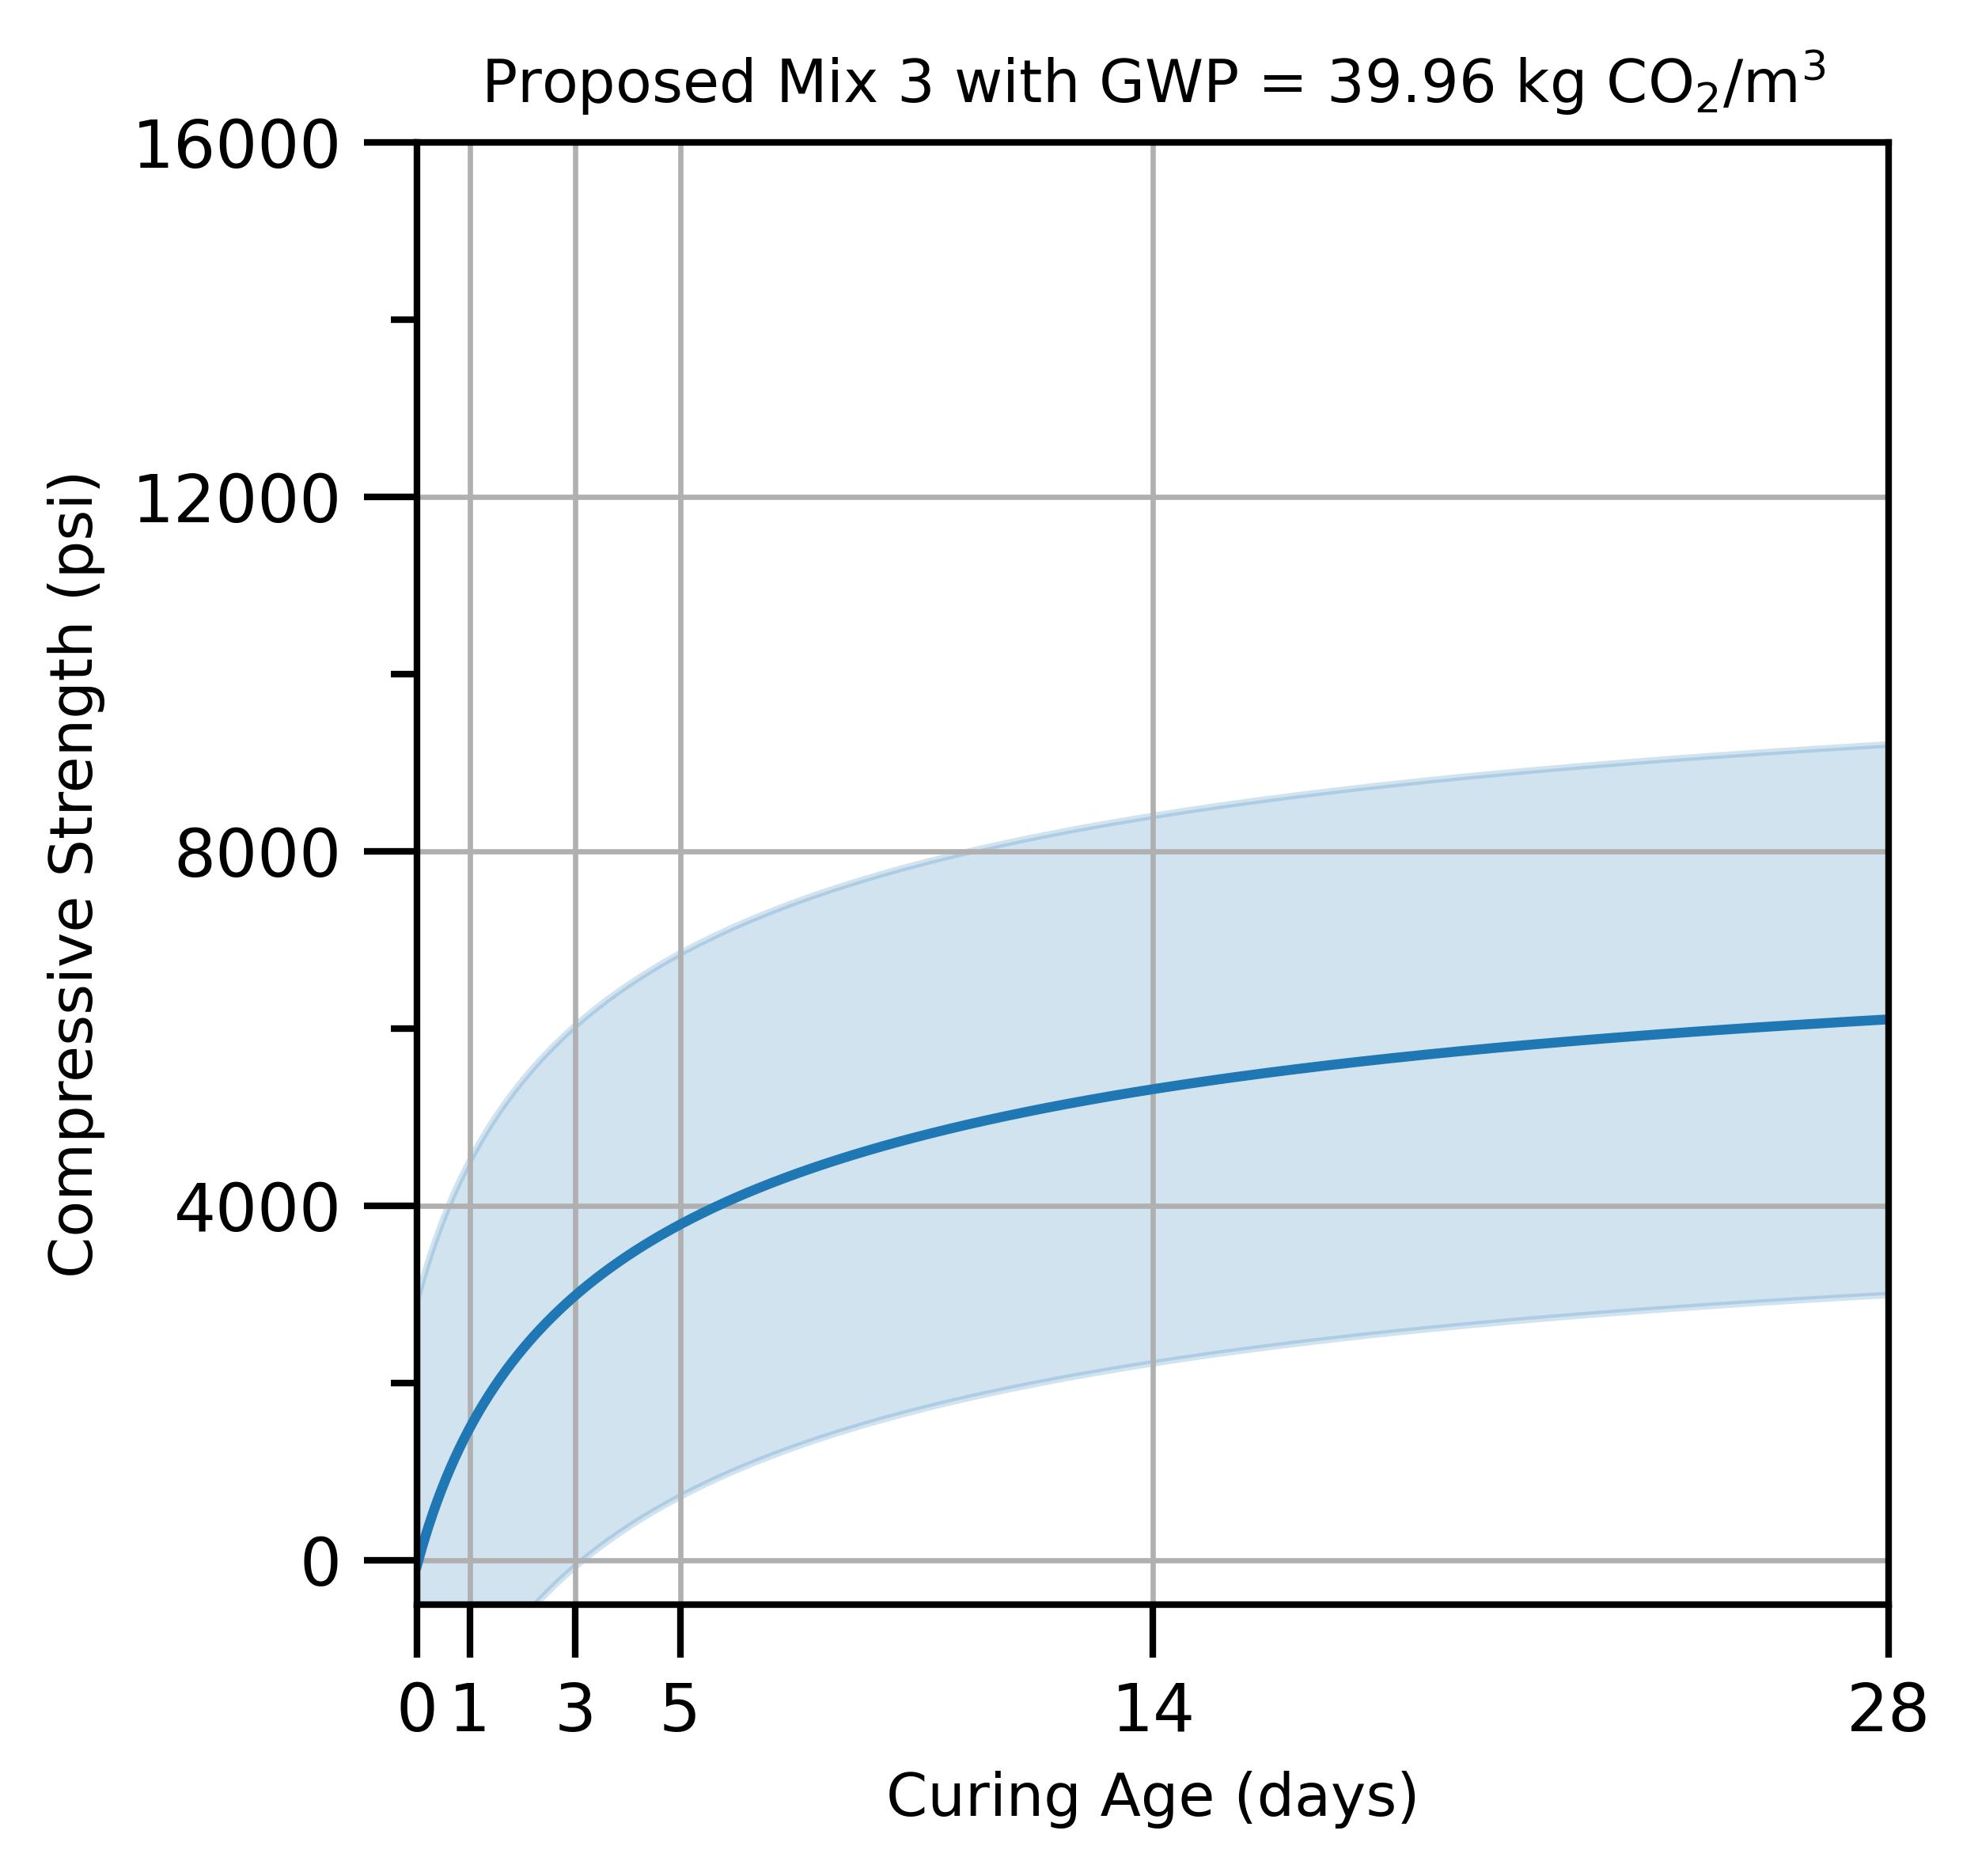

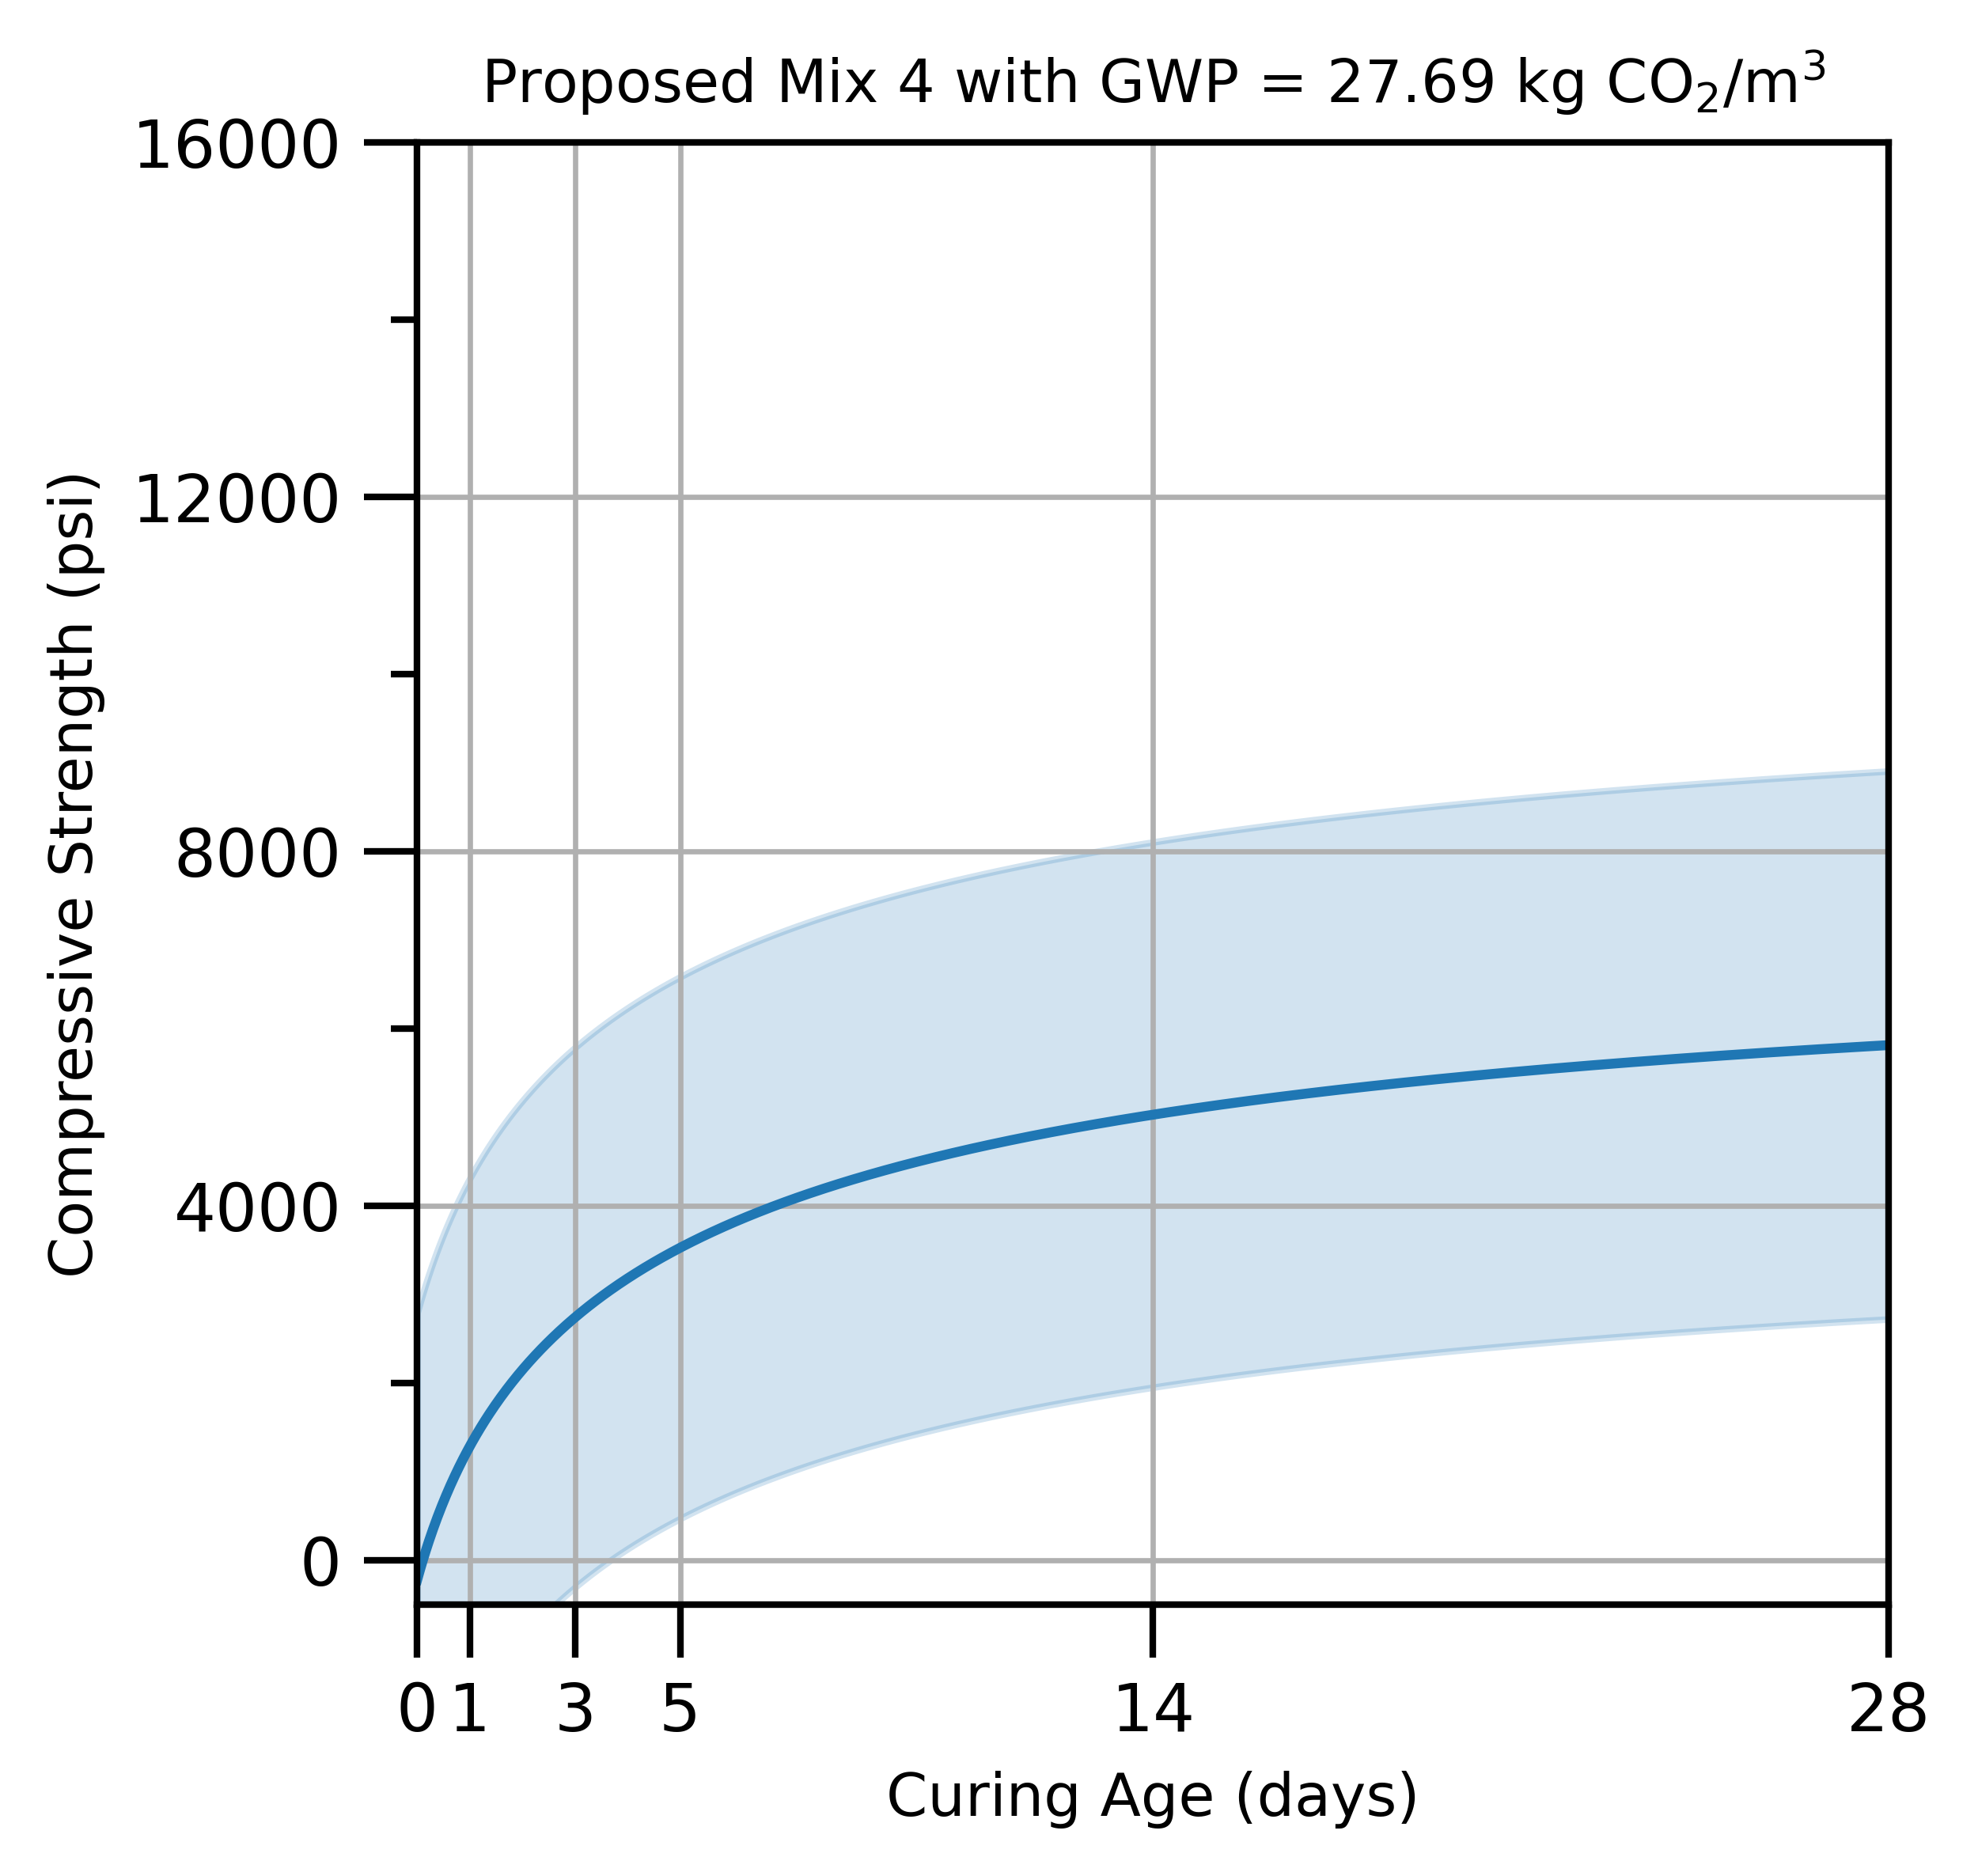

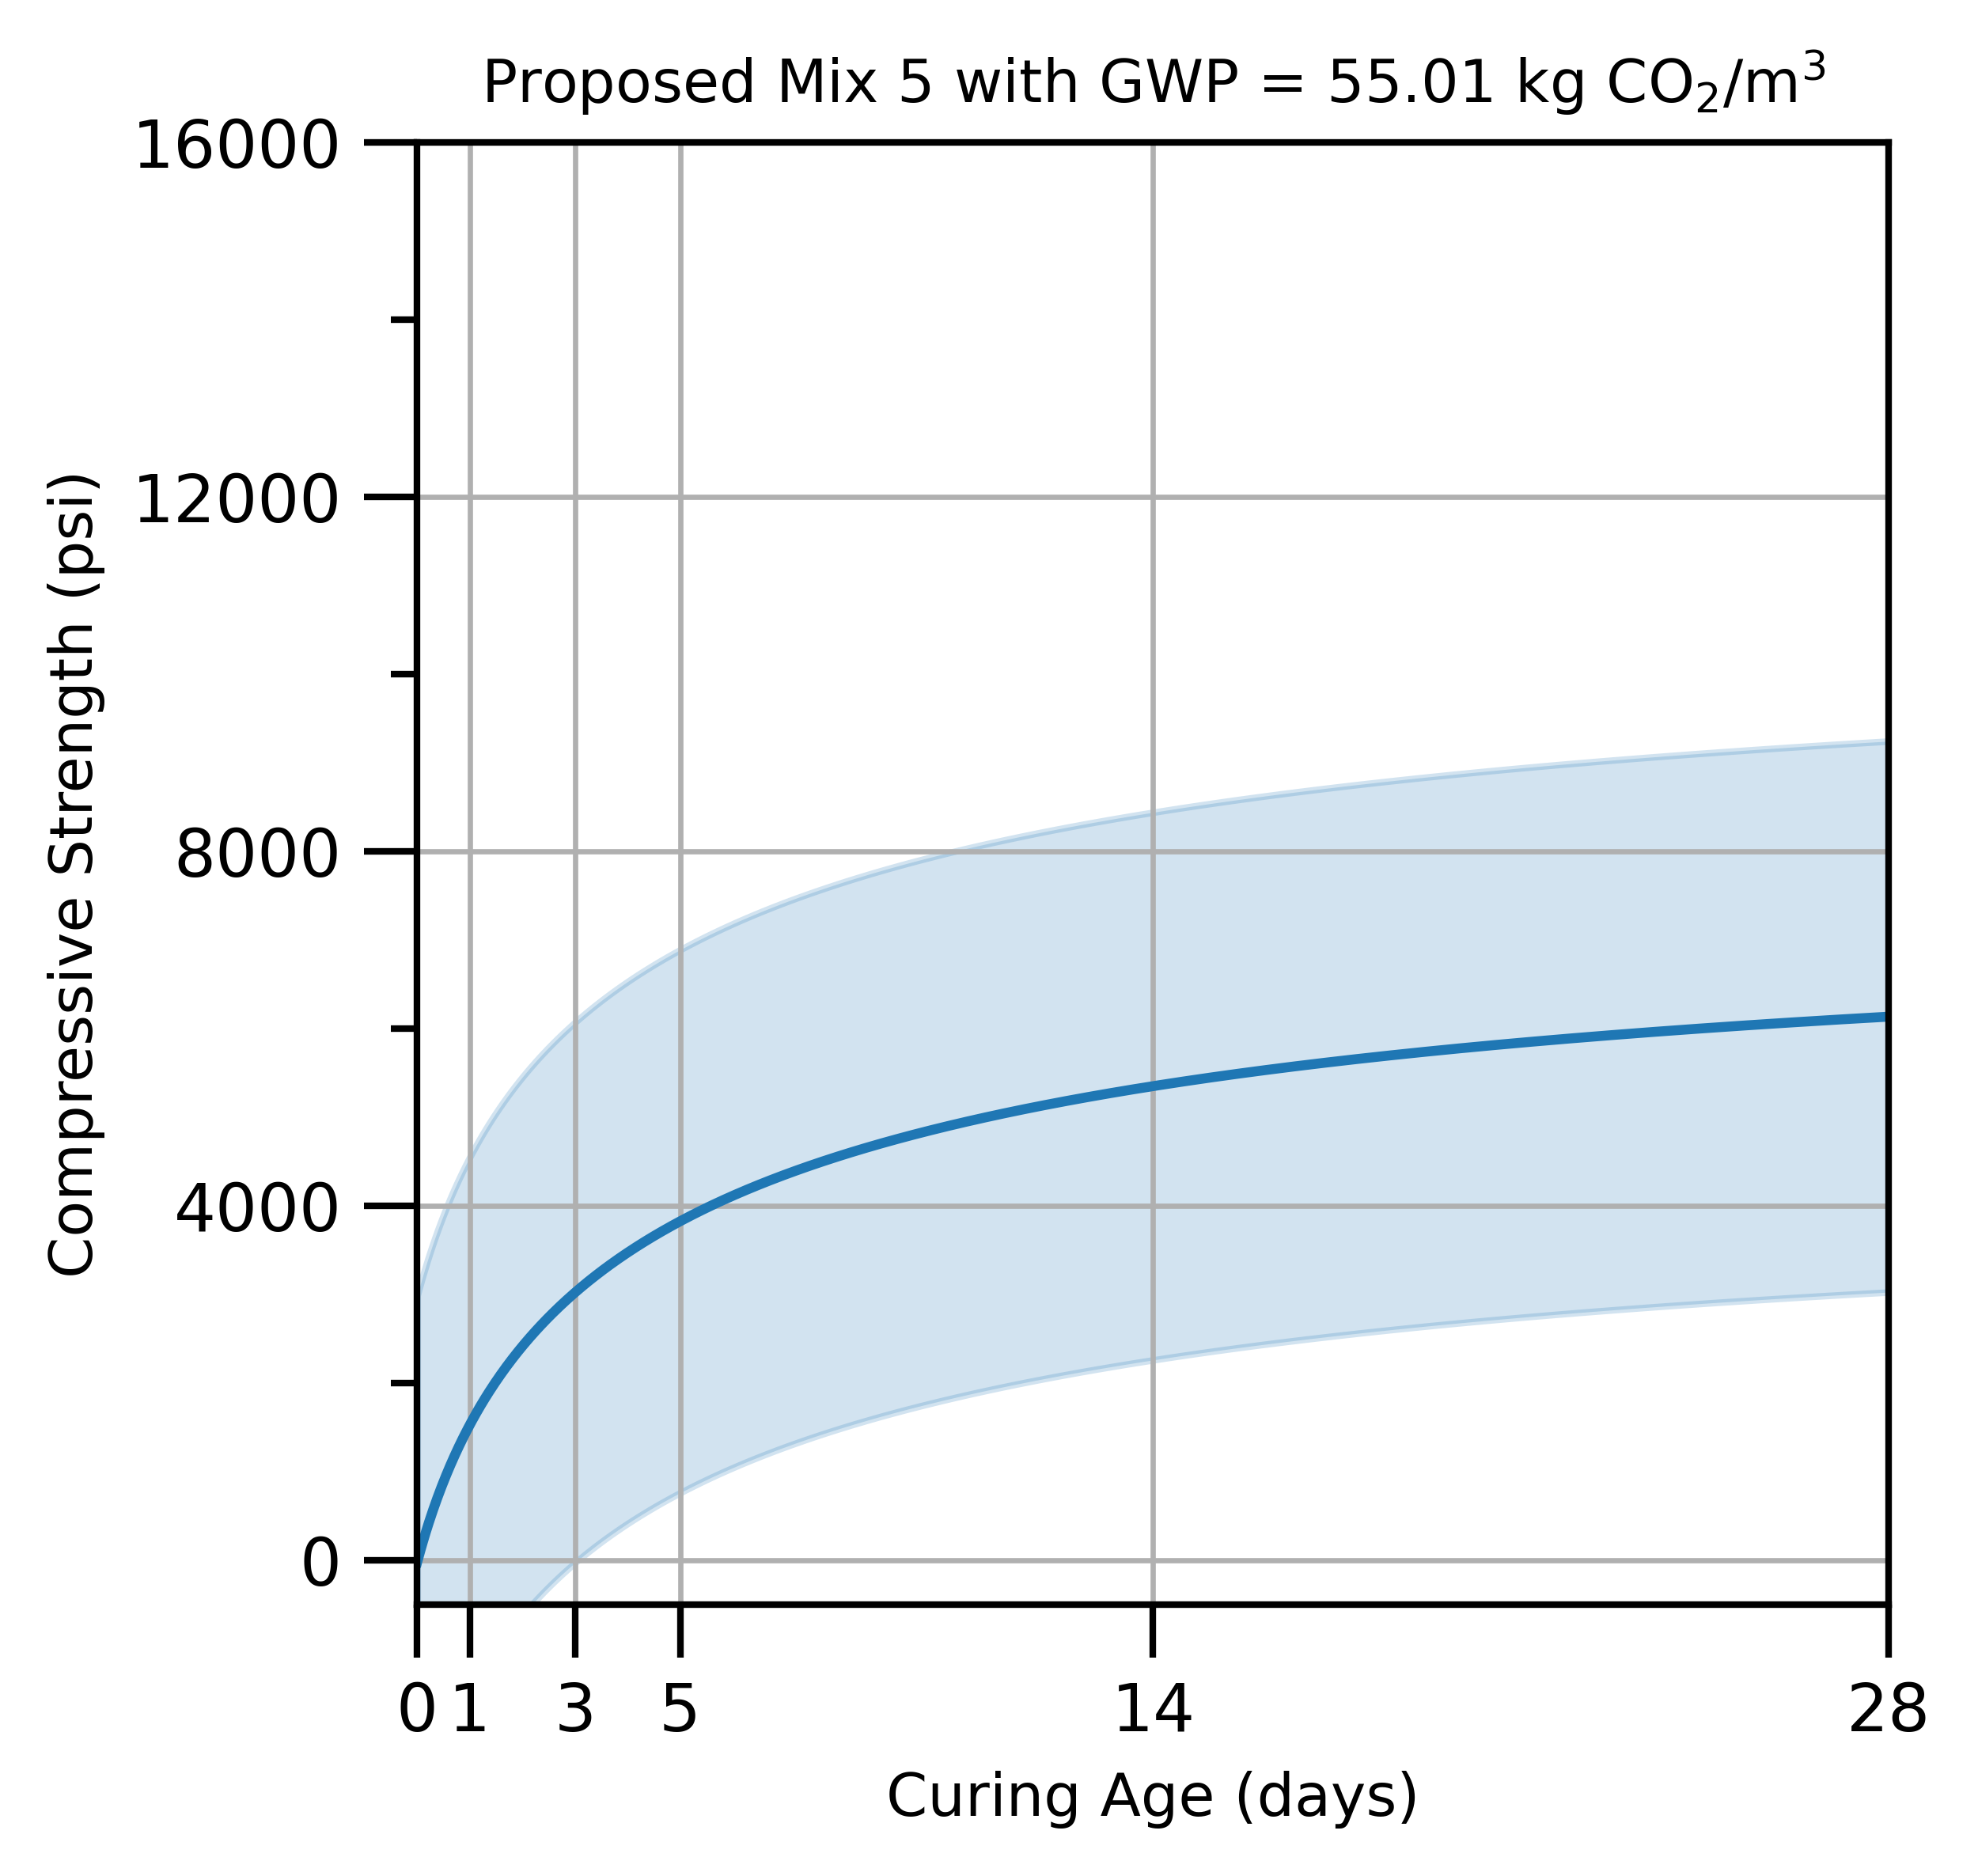

In [28]:
# Plot predicted strength curves for each proposed candidate
from boxcrete.plotting import plot_strength_curve

for i in range(q):
    # Map back to full composition space for plotting
    full_comp = torch.zeros(1, len(data.X_columns) - 1)
    free_idx = 0
    for j in range(len(data.X_columns) - 1):  # exclude Time
        if j in fixed_indices_no_time:
            full_comp[0, j] = fixed_features[j]
        else:
            full_comp[0, j] = X_next[i, free_idx]
            free_idx += 1
    plot_strength_curve(model, full_comp, title=f"Proposed Mix {i+1}")
    plt.show()